In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv")
df.head()

df['Children in HHS Care']=df['Children in HHS Care'].str.replace(',','').astype(int)
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    int64         
 2   Children in CBP custody                          720 non-null    int64         
 3   Children transferred out of CBP custody          720 non-null    int64         
 4   Children in HHS Care                             720 non-null    int64         
 5   Children discharged from HHS Care                720 non-null    int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 33.9 KB


In [16]:
''' EDA - Exploratory Data Analysis begines here '''
df=df.sort_values('Date')
df=df.set_index('Date')
df.head(5)

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33,53,34,6566,436
2023-01-22,32,49,39,7122,227
2023-01-23,32,50,39,7280,181
2023-01-24,47,42,47,7433,175
2023-01-25,20,22,41,7538,180


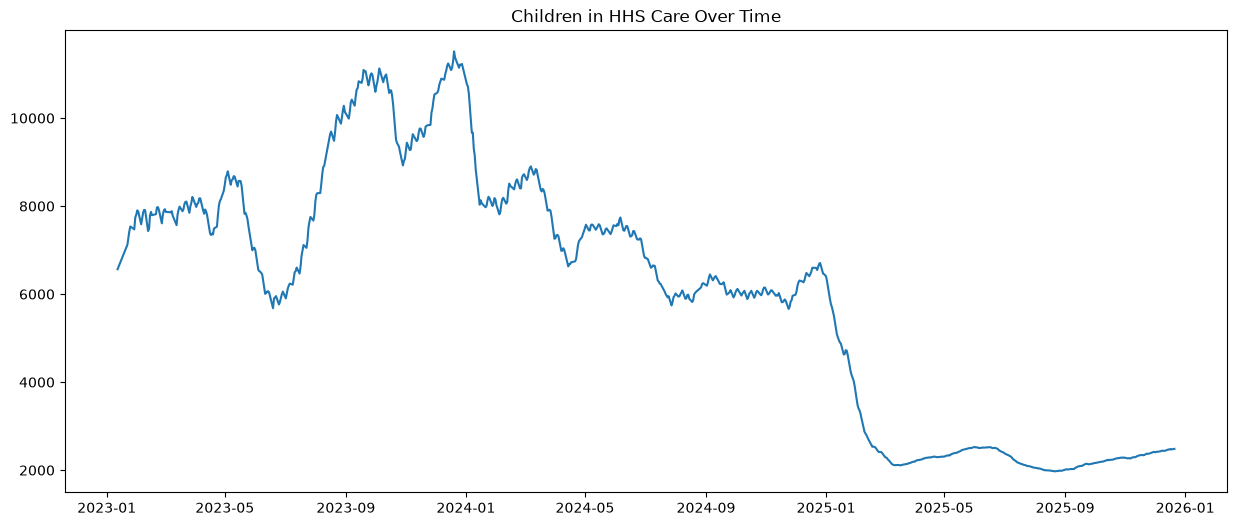

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
plt.plot(df["Children in HHS Care"])
plt.title("Children in HHS Care Over Time")
plt.show()

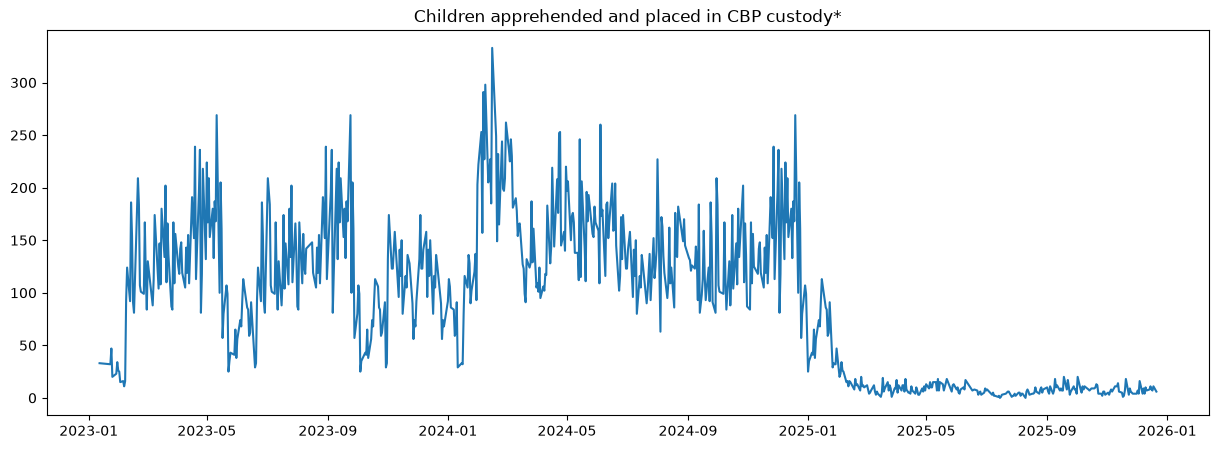

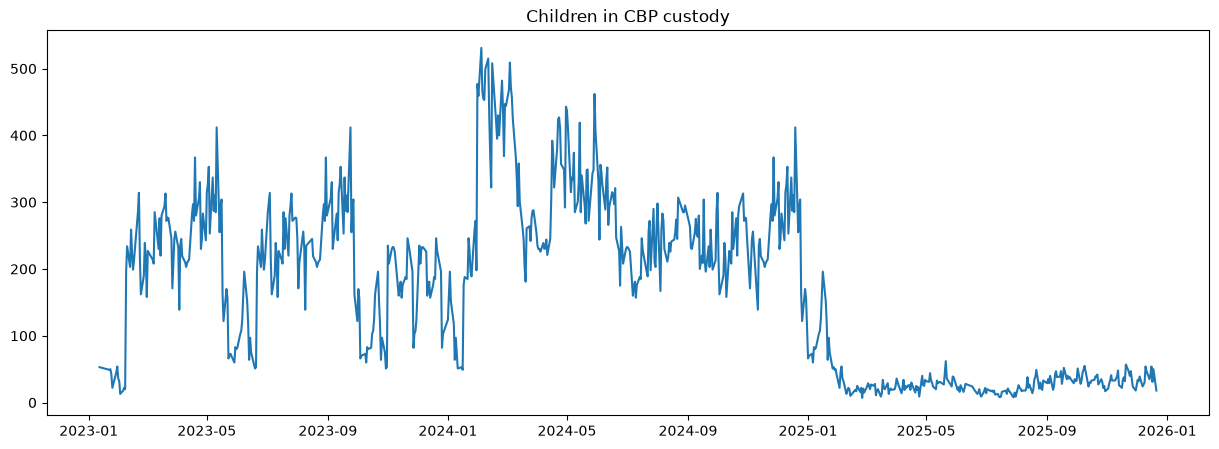

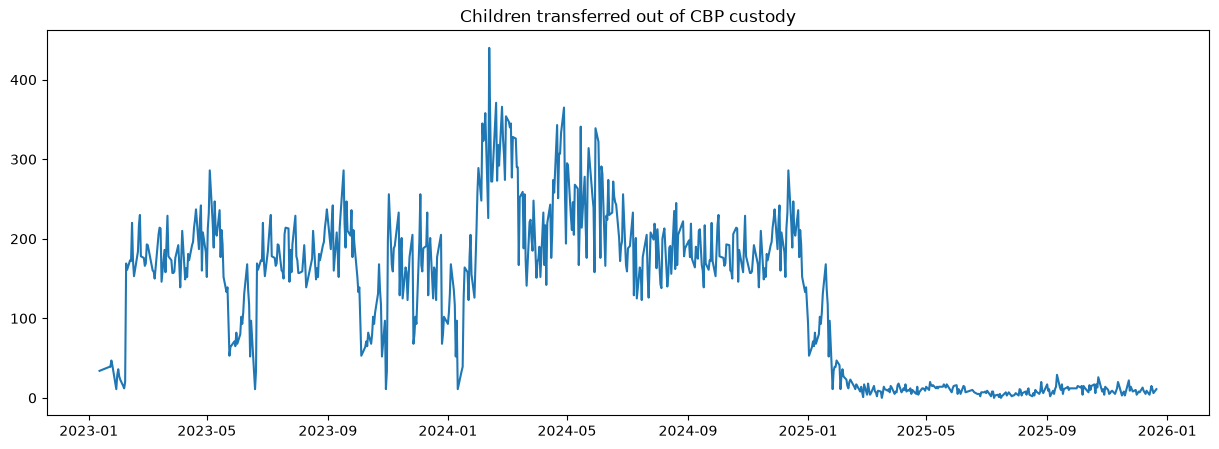

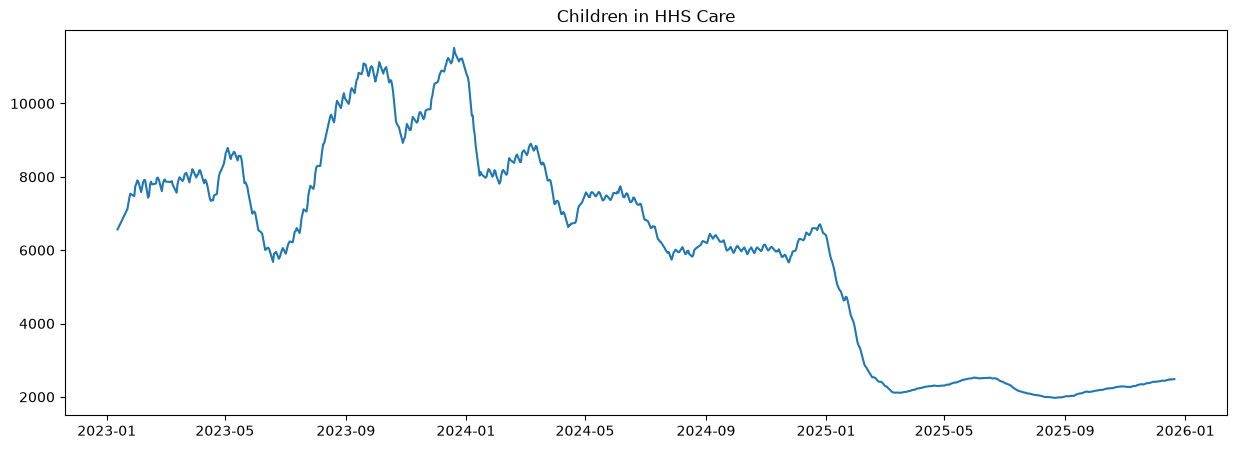

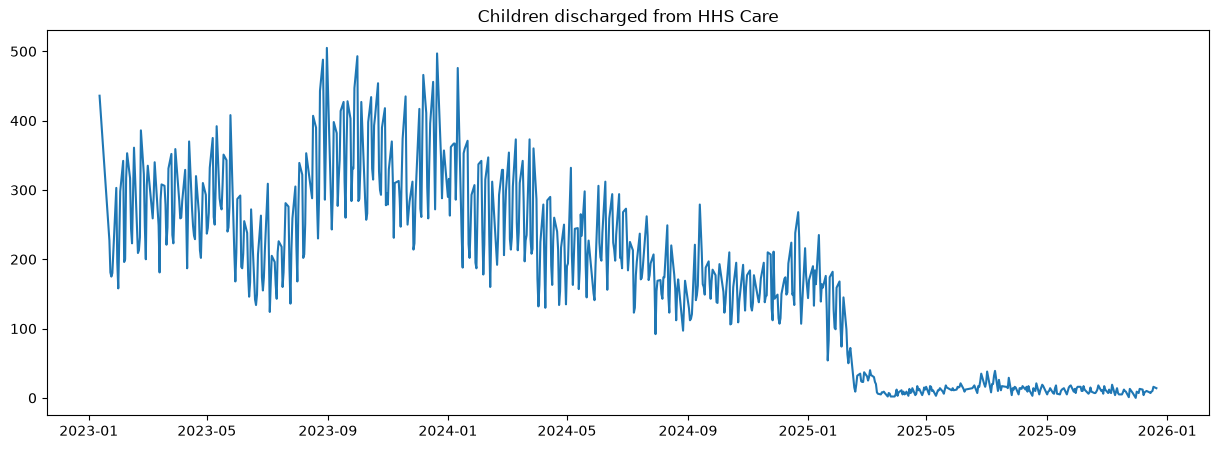

In [18]:
columns = df.columns

for col in columns:

    plt.figure(figsize=(15,5))

    plt.plot(df[col])

    plt.title(col)

    plt.show()

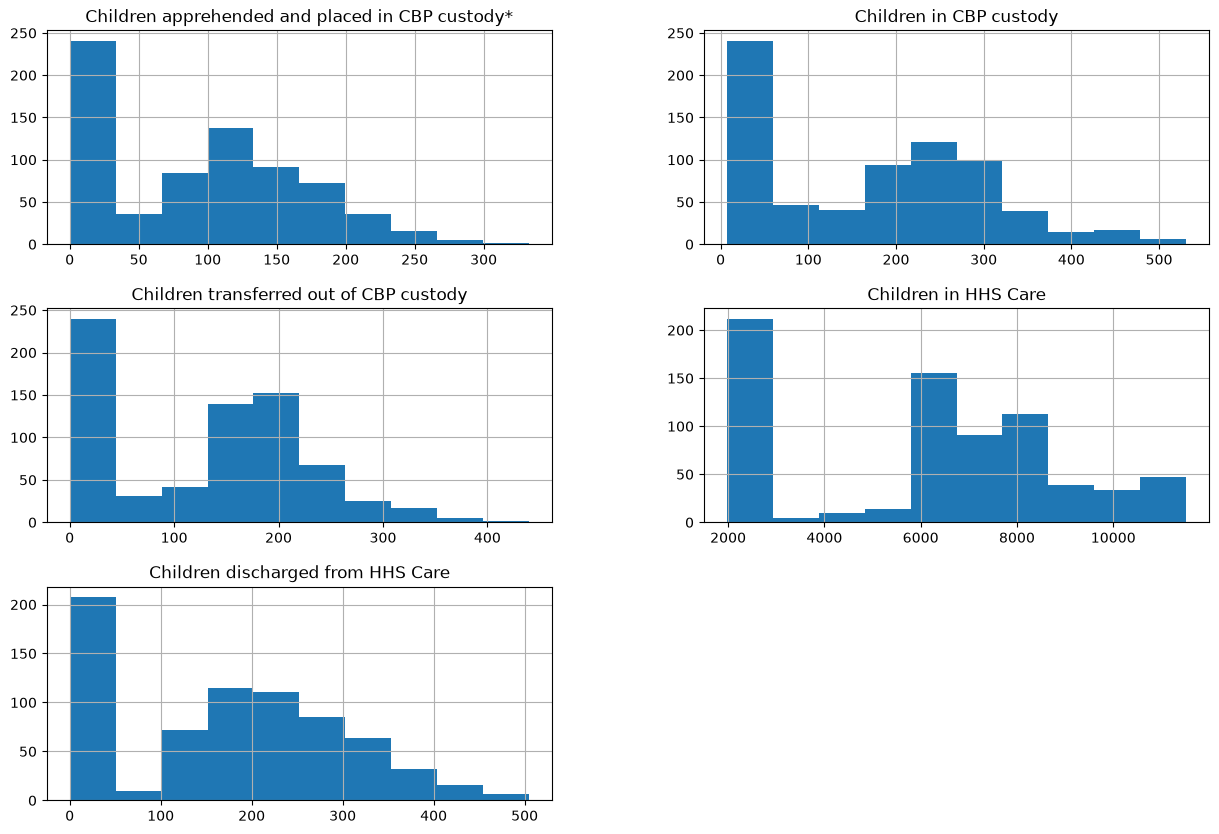

In [19]:
df.hist(figsize=(15,10))

plt.show()

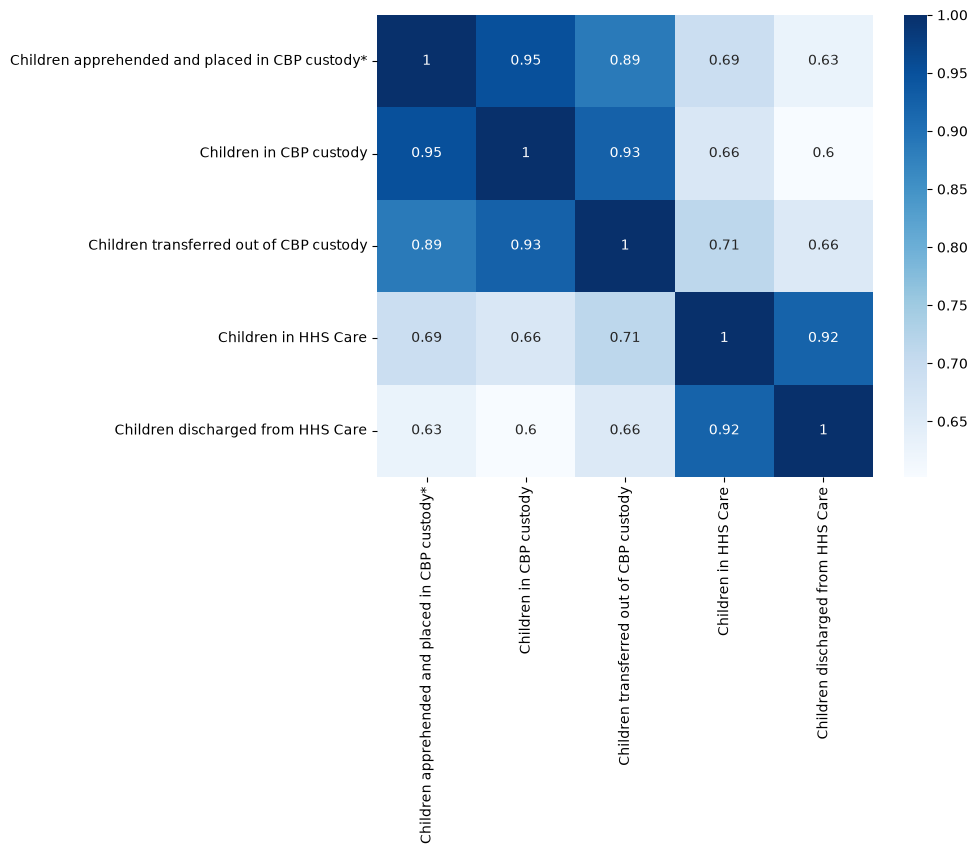

In [20]:
import seaborn as sns
corr = df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="Blues")

plt.show()

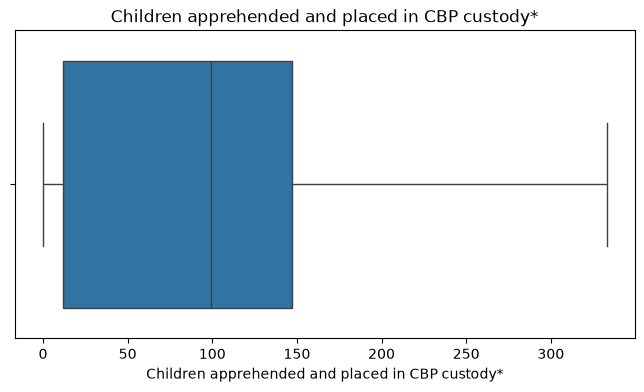

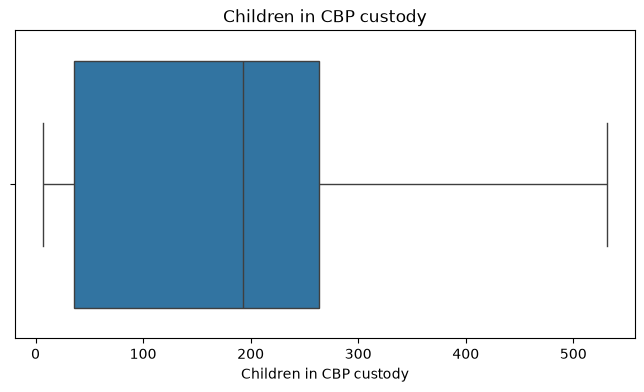

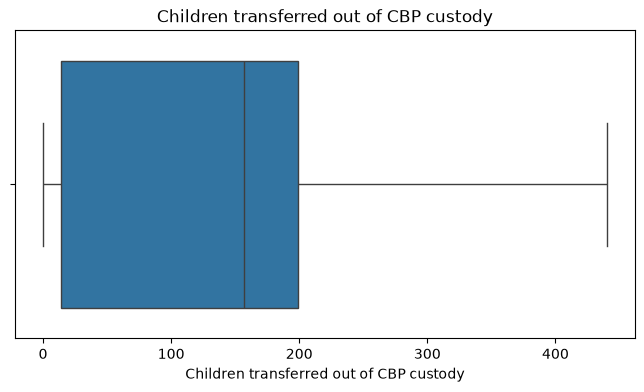

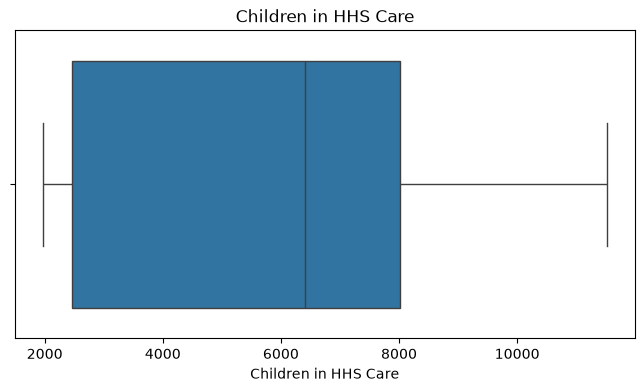

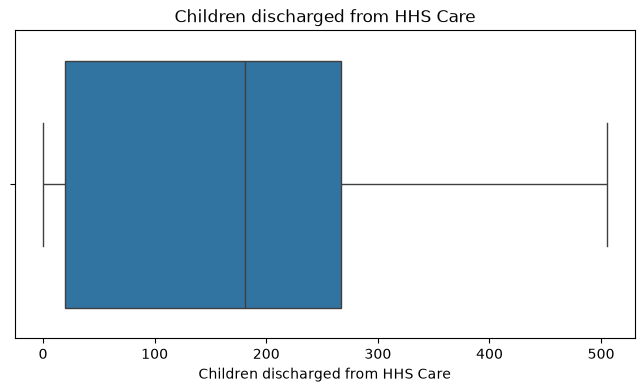

In [21]:
for col in df.columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

<Axes: xlabel='Month'>

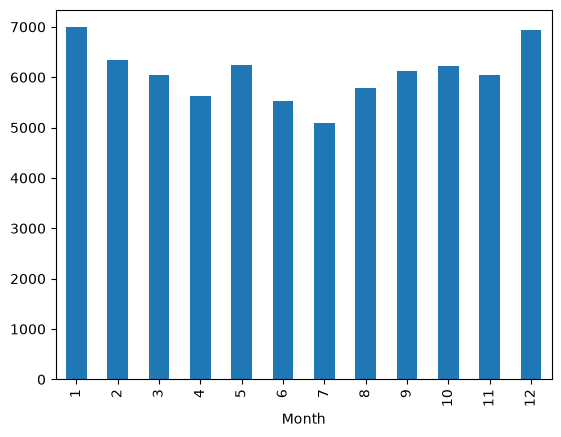

In [22]:
df["Month"] = df.index.month
monthly = df.groupby("Month")["Children in HHS Care"].mean()

monthly.plot(kind="bar")

<Axes: xlabel='Day', ylabel='Children in HHS Care'>

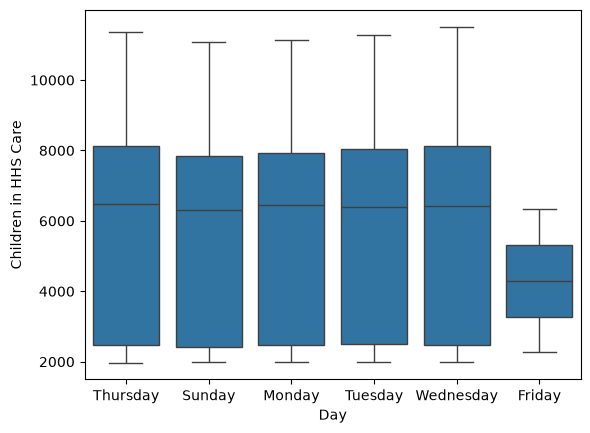

In [23]:
df["Day"] = df.index.day_name()
sns.boxplot(data=df,
            x="Day",
            y="Children in HHS Care")

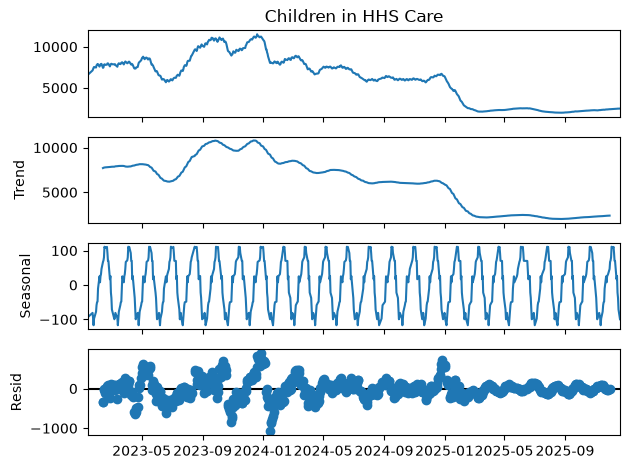

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df["Children in HHS Care"],
    model="additive",
    period=30
)

result.plot()

plt.show()